In [150]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set (color_codes = True)
%matplotlib inline
from scipy.stats import ttest_1samp, ttest_ind, mannwhitneyu, levene, shapiro
from statsmodels.stats.power import ttest_power
#importing the necessary libraries

In [151]:
#uploading the csv file to google colab from google drive
from google.colab import files
uploaded = files.upload()                                                       

ModuleNotFoundError: No module named 'google'

In [152]:
# loading the Insurance dataset
ins = pd.read_csv('insurance.csv')


In [153]:
# to  view the dataframe
ins.head(5)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [154]:
# Shape of the data set
ins.shape

(1338, 7)

In [155]:
# Describing the data set
ins.describe(include="all")

,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


In [156]:
# Information of each attribute in the data set
ins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
age         1338 non-null int64
sex         1338 non-null object
bmi         1338 non-null float64
children    1338 non-null int64
smoker      1338 non-null object
region      1338 non-null object
charges     1338 non-null float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.2+ KB


In [157]:
# Data type of each attribute
ins.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [158]:
# Checking the presence of missing values
ins.isnull()

,age,sex,bmi,children,smoker,region,charges
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False
6,False,False,False,False,False,False,False
7,False,False,False,False,False,False,False
8,False,False,False,False,False,False,False
9,False,False,False,False,False,False,False


In [159]:
# 5 point summary of numerical attributes like Mean, Max, Min, Q1, Q3
ins.mean()

age            39.207025
bmi            30.663397
children        1.094918
charges     13270.422265
dtype: float64

In [160]:
ins.max()

age                64
sex              male
bmi             53.13
children            5
smoker            yes
region      southwest
charges       63770.4
dtype: object

In [161]:
ins.min()

age                18
sex            female
bmi             15.96
children            0
smoker             no
region      northeast
charges       1121.87
dtype: object

In [162]:
ins.quantile([.1, .25, .5, .75], axis = 0)

,age,bmi,children,charges
0.10,19.0,22.99000,0.0,2346.533615
0.25,27.0,26.29625,0.0,4740.287150
0.50,39.0,30.40000,1.0,9382.033000
0.75,51.0,34.69375,2.0,16639.912515


array([[<matplotlib.axes._subplots.AxesSubplot object at 0x000001629D1ECF28>,
      dtype=object)

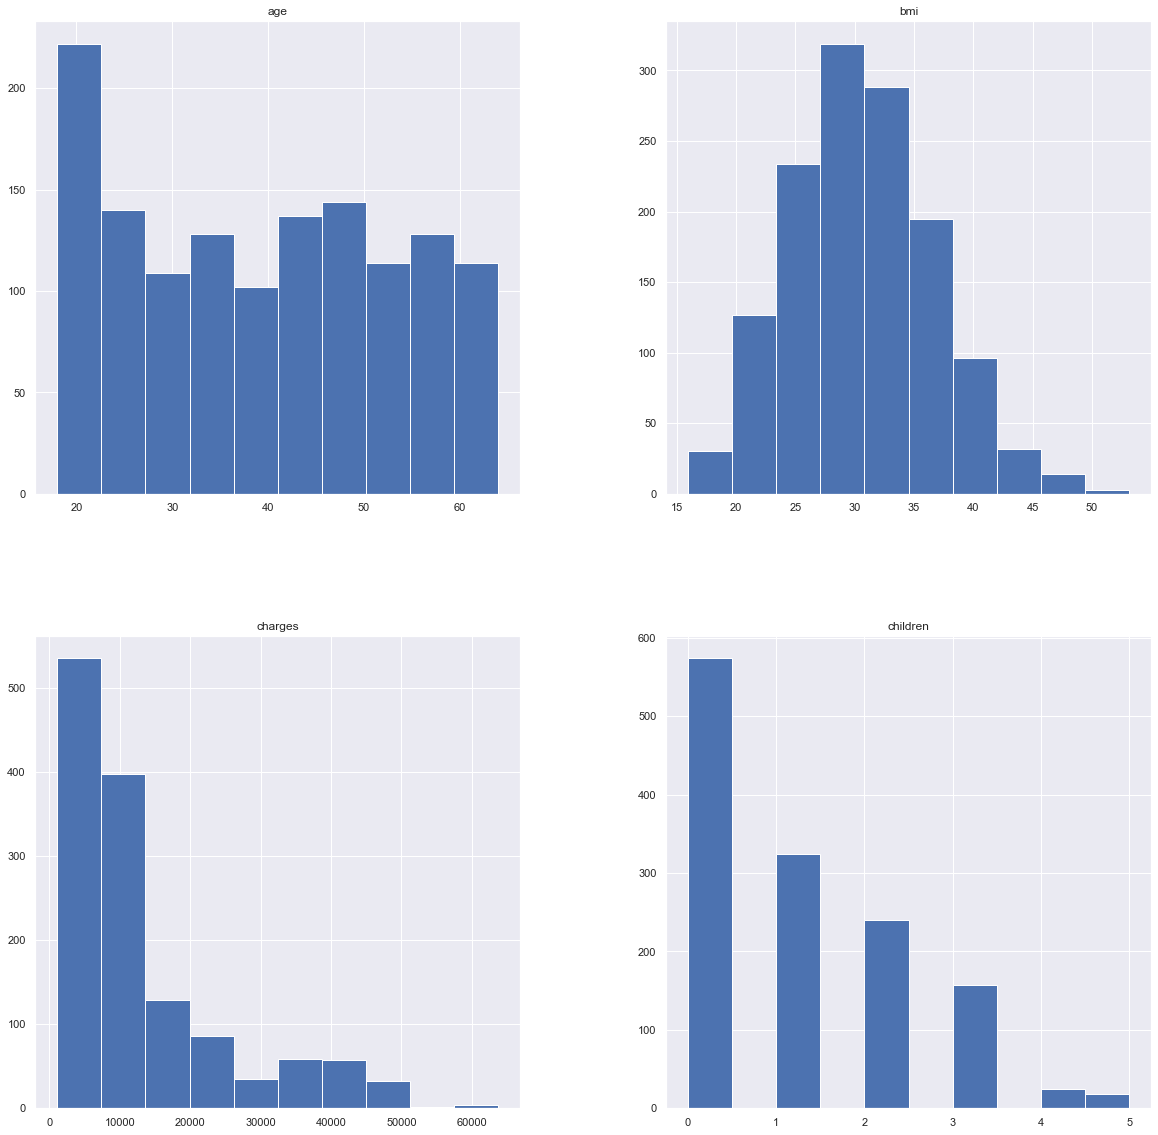

In [163]:
# Distribution of ‘bmi’, ‘age’ and ‘charges’ columns.
ins.hist(figsize=(20,20))

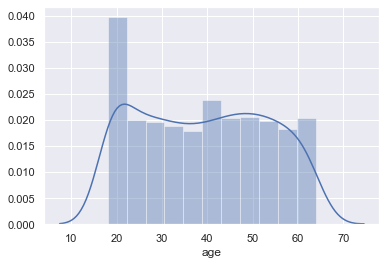

In [164]:
sns.distplot(ins['age'])


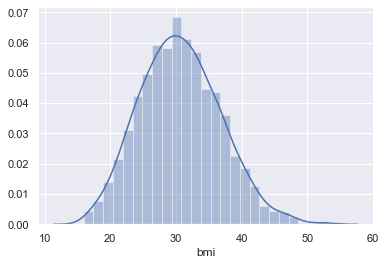

In [165]:
sns.distplot(ins['bmi'])

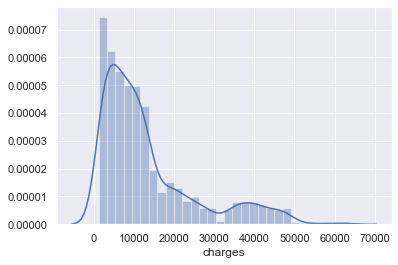

In [166]:
sns.distplot(ins['charges'])


In [167]:
# Measure of skewness of ‘bmi’, ‘age’ and ‘charges’
ins.skew()

age         0.055673
bmi         0.284047
children    0.938380
charges     1.515880
dtype: float64

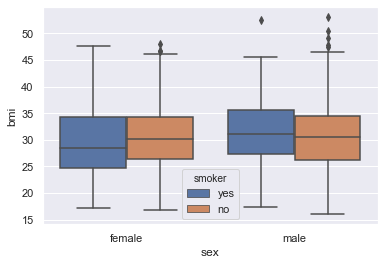

In [168]:
# Checking the presence of outliers in ‘bmi’, ‘age’ and ‘charges’ columns. # Five Number Summary by Box Plots
sns.boxplot(ins['sex'], ins['bmi'], hue=ins['smoker'])

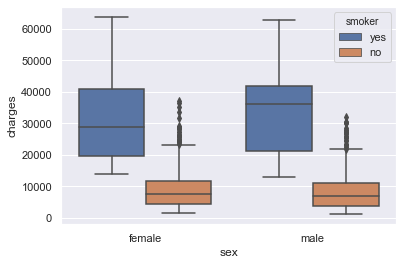

In [169]:
sns.boxplot(ins['sex'], ins['charges'], hue=ins['smoker'])

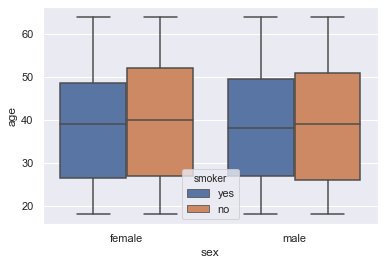

In [170]:
sns.boxplot(ins['sex'], ins['age'], hue=ins['smoker'])

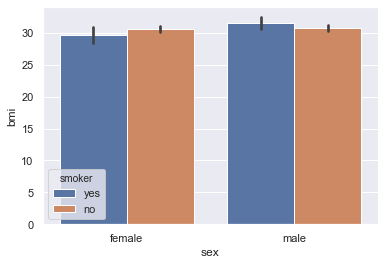

In [171]:
# Relational Distributions

sns.barplot(ins['sex'], ins['bmi'], hue=ins['smoker'])                             

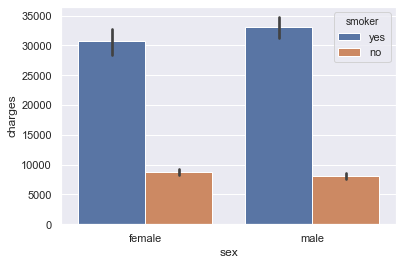

In [172]:
sns.barplot(ins['sex'], ins['charges'], hue=ins['smoker'])

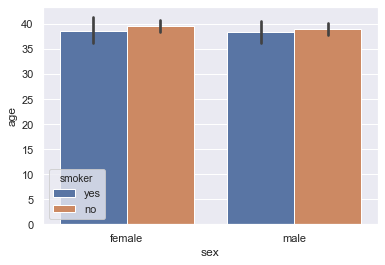

In [173]:
sns.barplot(ins['sex'], ins['age'], hue=ins['smoker'])

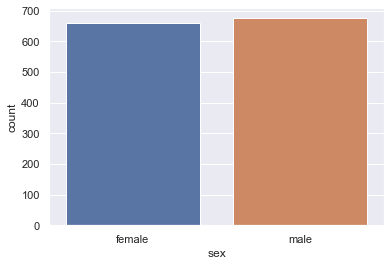

In [174]:
# Distribution of Categorical Columns
sns.countplot(ins['sex'])

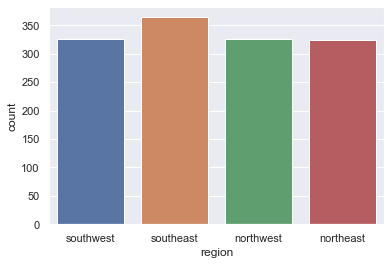

In [175]:
sns.countplot(ins['region'])

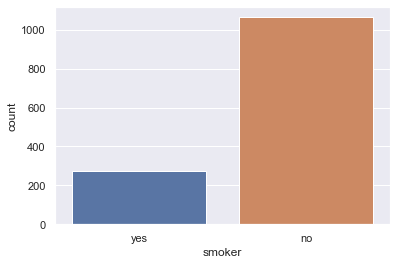

In [176]:
sns.countplot(ins['smoker'])

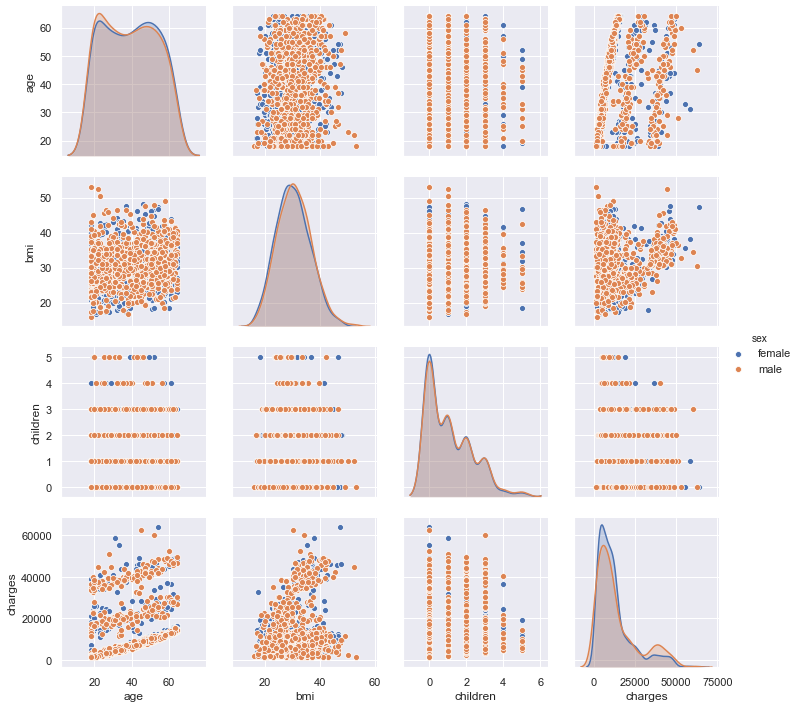

In [177]:
sns.pairplot(ins, hue="sex", kind='scatter')

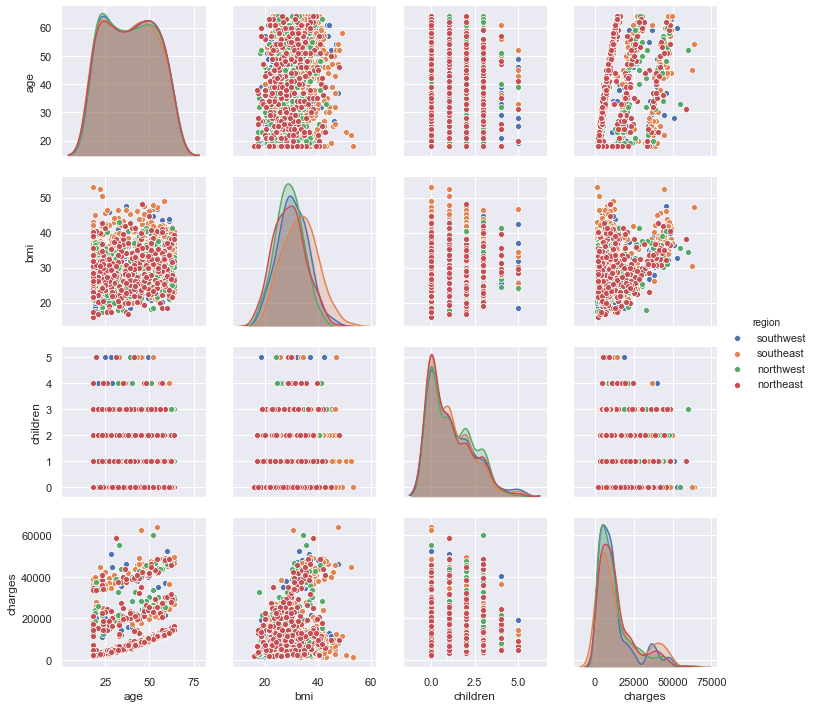

In [178]:
sns.pairplot(ins, hue="region", kind='scatter')

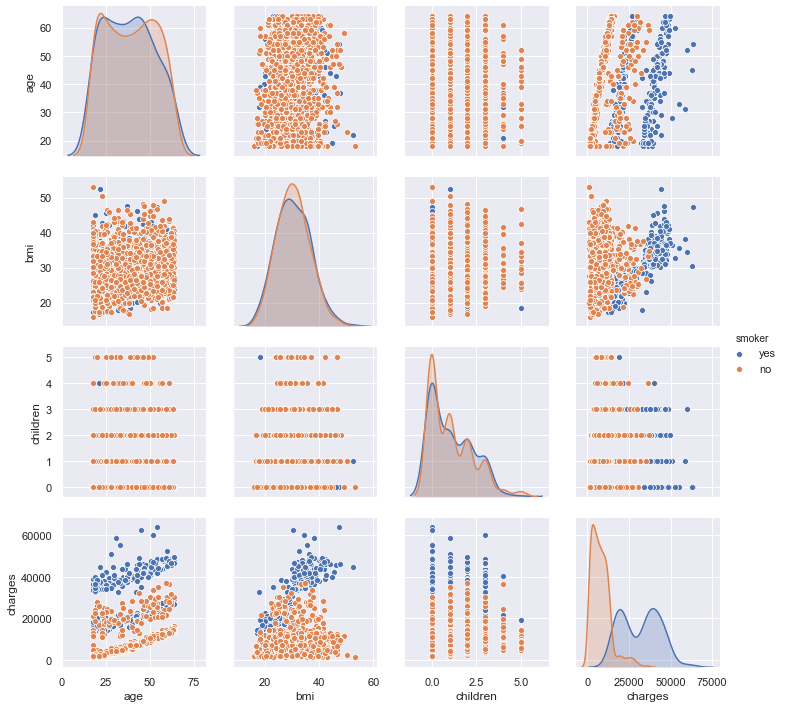

In [179]:
sns.pairplot(ins, hue="smoker", kind='scatter')

In [180]:
corr= ins.corr()
corr

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


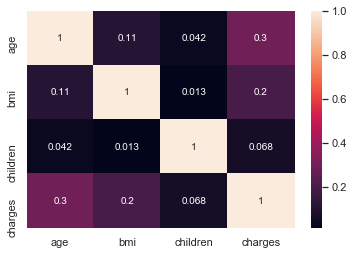

In [181]:
sns.heatmap(corr, annot=True)

In [182]:

ins.std()

age            14.049960
bmi             6.098187
children        1.205493
charges     12110.011237
dtype: float64

In [183]:
ins.var()

age         1.974014e+02
bmi         3.718788e+01
children    1.453213e+00
charges     1.466524e+08
dtype: float64

The below chart shows that charges of people who smoke differ significantly from the people who don't 


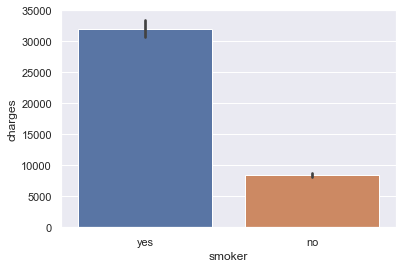

In [184]:
# Answer to the question "Do charges of people who smoke differ significantly from the people who don't? "
sns.barplot(ins['smoker'], ins['charges'])

print("The below chart shows that charges of people who smoke differ significantly from the people who don't ")

Here the below bar chart shows that the bmi of males and females.
There is no significant change in bmi of males from that of females


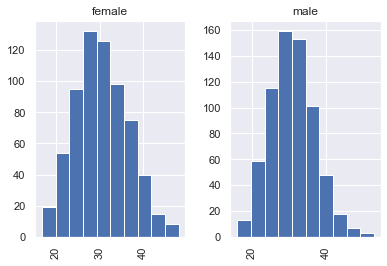

In [41]:
# Answer to the question "Does bmi of males differ significantly from that of females?"
ins.hist(by='sex', column='bmi',bins=10)
print("Here the below bar chart shows that the bmi of males and females.")
print("There is no significant change in bmi of males from that of females")

from the below plot, The proportion of smokers significantly different in different genders 


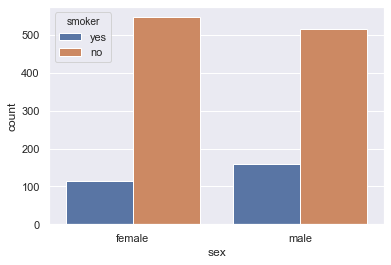

In [42]:
# Answer to the question "Is the proportion of smokers significantly different in different genders?"
#yes, The proportion of smokers significantly different in different genders
sns.countplot(ins['sex'], hue=ins['smoker'])

print("from the below plot, The proportion of smokers significantly different in different genders ")

In [45]:
# bmi for most of the persons
bmi_tmp = pd.crosstab(index=ins["bmi"], columns="count")
bmi_tmp.reset_index(inplace=True)
bmi_tmp[bmi_tmp['count'] == ins.bmi.value_counts().max()]

col_0,bmi,count
312,32.3,13


In [46]:
#4.a) Do charges of people who smoke differ significantly  from the people who don't?  

# Ho = charges of people who smoke differ significantly  from the people who don't?
# Ha = charges of people who smoke not differ significantly  from the people who don't?

In [143]:
group1 = ins[ins['smoker']=='yes']['charges']
group2 = ins[ins['smoker']=='no']['charges']

In [144]:
t_statistic, p_value = ttest_ind(group1, group2)
print(t_statistic, p_value)

46.664921172723716 8.271435842177219e-283


In [149]:
print ("two-sample t-test p-value=", p_value)

two-sample t-test p-value= 0.08997637178984932


In [ ]:
# Hence charges differ signnificantly who smoke and who don't.

In [119]:
# 4.b) Does bmi of males differ significantly from that of  females

# Ho = bmi of males differ significantly from that of  females
# Ha = bmi of males not differ significantly from that of  females

In [146]:
grp1 = ins[ins['sex']=='male']['bmi']
grp2 = ins[ins['sex']=='female']['bmi']

In [147]:
t_statistic, p_value = ttest_ind(grp1, grp2)
print(t_statistic, p_value)

1.696752635752224 0.08997637178984932


In [148]:
print ("two-sample t-test p-value=", p_value)

two-sample t-test p-value= 0.08997637178984932


In [ ]:
# Hence, the bmi value is not differ significantly. We are failed to reject the null hypothesis.

In [ ]:
#4.c) Is the proportion of smokers significantly different
#in different genders?

# Ho = The proportion are equal

# Ha = The two proportion are not equal

In [102]:
female_smokers = ins[ins['sex'] == 'female'].smoker.value_counts()[1]  # number of female smokers
male_smokers = ins[ins['sex'] == 'male'].smoker.value_counts() [1]# number of male smokers
n_females = ins.sex.value_counts()[1] # number of females in the ins
n_males = ins.sex.value_counts() [0]#number of males in the ins

In [103]:
print([female_smokers, male_smokers] , [n_females, n_males])

[115, 159] [662, 676]


In [104]:
print(f' Proportion of smokers in females, males = {round(115/662,2)}%, {round(159/676,2)}% respectively')

 Proportion of smokers in females, males = 0.17%, 0.24% respectively


In [108]:
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.proportion import proportions_ztest

stat, pval = proportions_ztest([female_smokers, male_smokers] , [n_females, n_males])

if pval < 0.05:
    print(f'With a p-value of {round(pval,4)} the difference is significant. aka |We reject the null|')
else:
    print(f'With a p-value of {round(pval,4)} the difference is not significant. aka |We fail to reject the null|')

With a p-value of 0.0053 the difference is significant. aka |We reject the null|


 From the below First three bar graphs shows that the distribution of bmi across women with no children, one child and two children are not same.


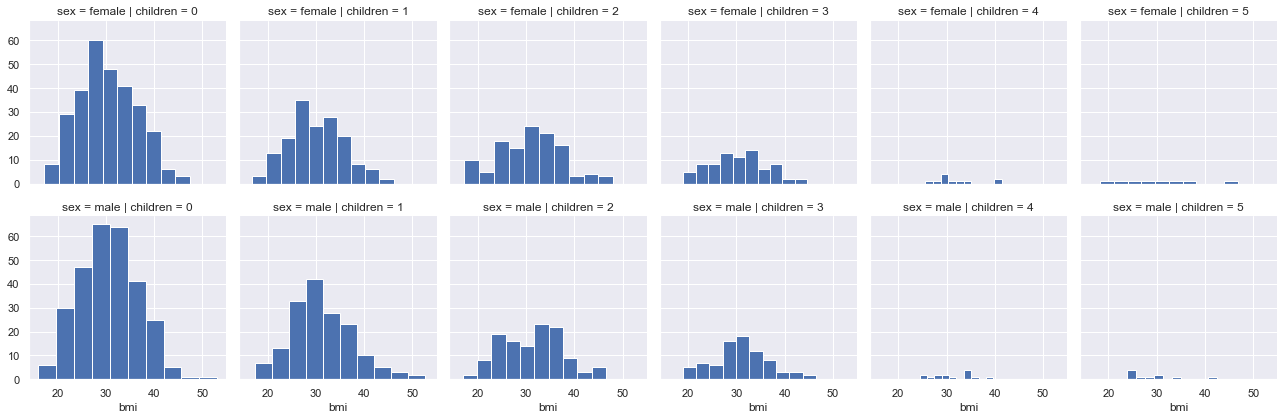

In [43]:
# Answer to the question "Is the distribution of bmi across women with no children, one child and two children, the same ?"

g=sns.FacetGrid(ins, row="sex", col="children")
g.map(plt.hist, "bmi")

print(" From the below First three bar graphs shows that the distribution of bmi across women with no children, one child and two children are not same.")